# 05 - EDA: Geographic Sentiment Analysis
## ShopEase Europe | Sentiment Analysis Project  
**Objective:** Analyse sentiment patterns across countries and regions 
to identify which markets are most satisfied and where ShopEase Europe 
has the greatest opportunity to improve customer experience.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the Data
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'clean_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Countries: {sorted(df['country'].unique())}")
print(f"Total countries: {df['country'].nunique()}")

Dataset loaded: 120,000 rows x 14 columns
Countries: ['AR', 'AT', 'AU', 'BE', 'CA', 'CH', 'CO', 'DE', 'ES', 'FR', 'GB', 'IE', 'MX', 'US']
Total countries: 14


## 1.0 Sentiment Distribution by Country
Which markets are ShopEase Europe's strongest performers and where 
is customer satisfaction lowest? Country-level sentiment analysis 
helps regional teams prioritise improvement efforts.

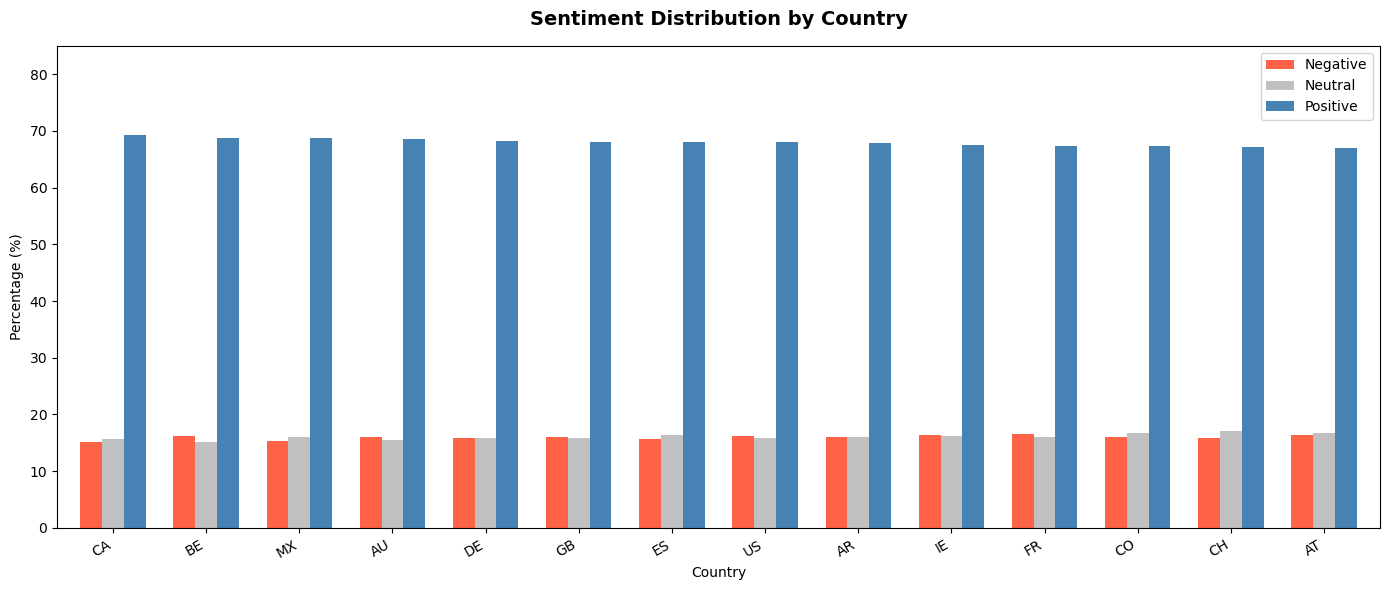

In [3]:
# Sentiment percentage by country
country_sentiment = df.groupby(['country', 'sentiment']).size().unstack(fill_value=0)
country_sentiment_pct = country_sentiment.div(country_sentiment.sum(axis=1), axis=0) * 100
country_sentiment_pct = country_sentiment_pct.round(2)

# Sort by positive sentiment descending
country_sentiment_pct = country_sentiment_pct.sort_values('positive', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

country_sentiment_pct.plot(
    kind='bar',
    ax=ax,
    color=['tomato', 'silver', 'steelblue'],
    width=0.7,
    edgecolor='none'
)

ax.set_title('Sentiment Distribution by Country', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Negative', 'Neutral', 'Positive'], loc='upper right')
ax.set_ylim(0, 85)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'sentiment_by_country.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight
Canada (CA) and Belgium (BE) lead in positive sentiment while Ireland 
(IE) records the lowest positive sentiment among all 14 markets. 
However the variation between the highest and lowest performing 
markets is narrow, indicating broadly consistent customer satisfaction 
across all regions ShopEase Europe operates in.

Markets in the Americas, Canada, Mexico, and Argentina, perform 
comparably to European markets, suggesting the customer experience 
is consistent regardless of geography. For the regional operations 
team, Ireland and Argentina represent the markets with the greatest 
opportunity to improve positive sentiment, even if the gap is small.

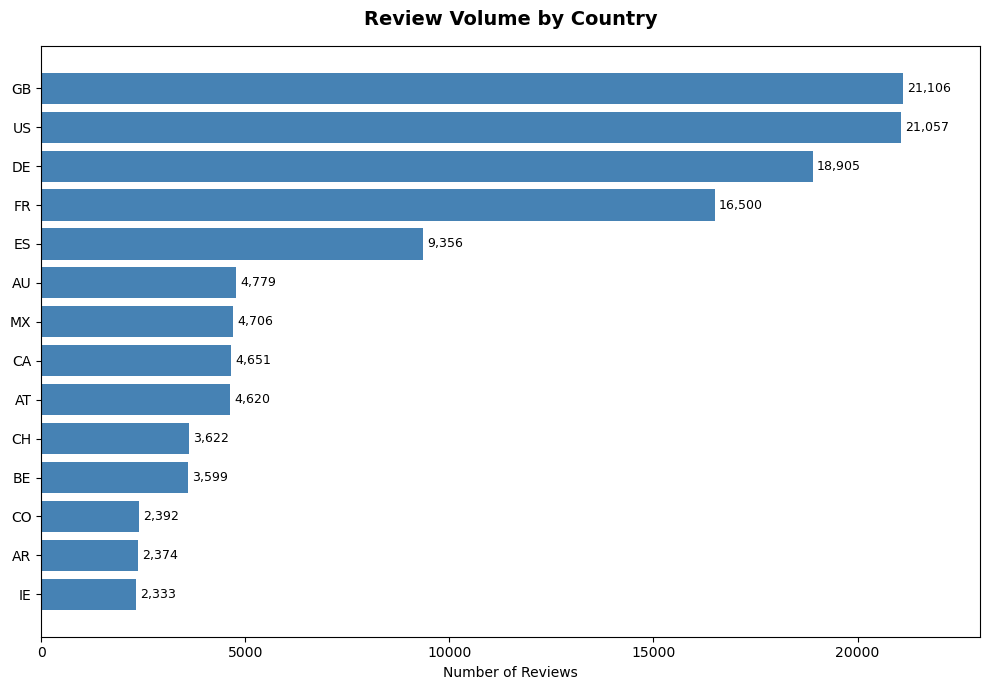

In [6]:
# Review volume by country
country_counts = df['country'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(country_counts.index, country_counts.values, color='steelblue')

ax.set_title('Review Volume by Country', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews')
ax.set_xlim(0, 23000)
ax.grid(False)

for bar, count in zip(bars, country_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'review_volume_by_country.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight
GB and US are ShopEase Europe's highest volume markets, generating 
21,106 and 21,057 reviews respectively, together accounting for 
35% of all customer feedback. Germany and France follow with 18,905 
and 16,500 reviews, reflecting their significance as major European 
retail markets.

There is a notable drop after the top four markets, with Spain 
generating 9,356 reviews and all remaining markets below 5,000. 
Ireland, Colombia and Argentina represent the lowest volume markets 
at approximately 2,300-2,400 reviews each.

For ShopEase Europe's regional strategy, the concentration of 
feedback in GB, US, DE and FR means sentiment insights from these 
markets carry the greatest statistical reliability. Findings from 
smaller markets should be interpreted with appropriate caution given 
the lower sample sizes.

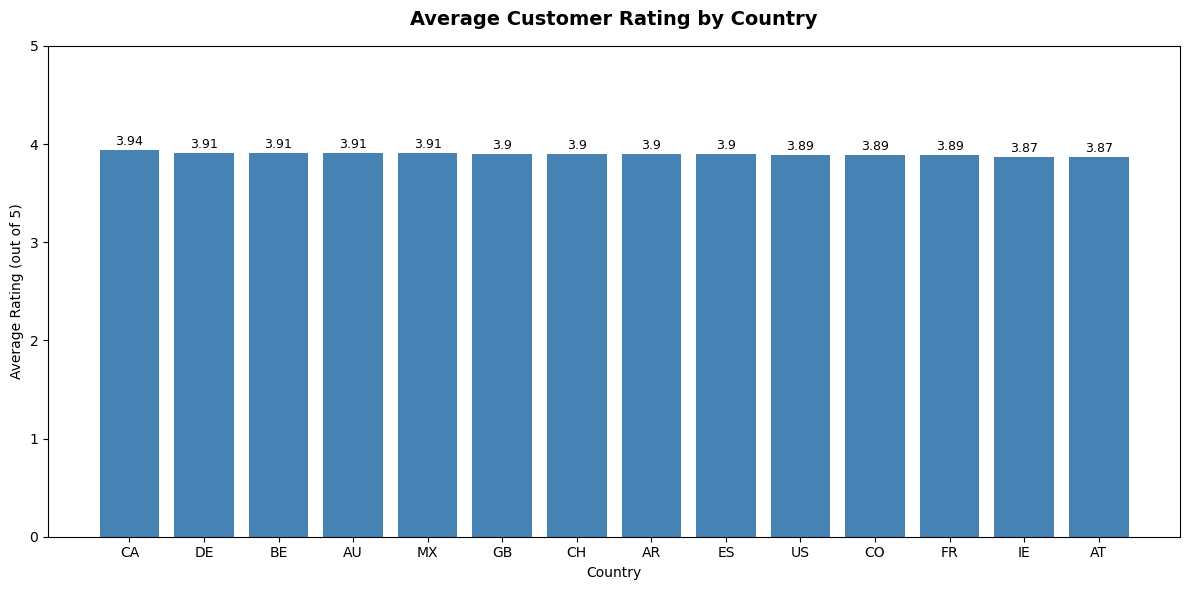

In [7]:
# Average rating by country
avg_rating_country = df.groupby('country')['rating'].mean().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(avg_rating_country.index, avg_rating_country.values, color='steelblue')

ax.set_title('Average Customer Rating by Country',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Average Rating (out of 5)')
ax.set_ylim(0, 5)
ax.grid(False)

for bar, rating in zip(bars, avg_rating_country.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(rating), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'avg_rating_by_country.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

Canada leads all markets with an average rating of 3.94, followed 
by Germany, Belgium and Australia at 3.91. Ireland and Austria sit 
at the bottom at 3.87, the lowest rated markets across the entire 
customer base.

While the overall range is narrow at just 0.07 points, these 
rankings provide ShopEase Europe's regional teams with a clear 
priority order. Canada and Germany represent the strongest customer 
experience markets, while Ireland and Austria combined with their 
lower review volumes, signal markets where targeted improvement 
initiatives could yield measurable gains in customer satisfaction.

# Product Category Performance by Country
Which product categories drive the most reviews in each market, 
and which country contributes the highest volume for each category?


Sports               GB         2,741 reviews
Toys                 US         2,723 reviews
Beauty               GB         2,662 reviews
Books                US         2,651 reviews
Electronics          GB         2,631 reviews
Fashion              US         2,614 reviews
Home & Living        GB         2,612 reviews
Food & Grocery       GB         2,611 reviews


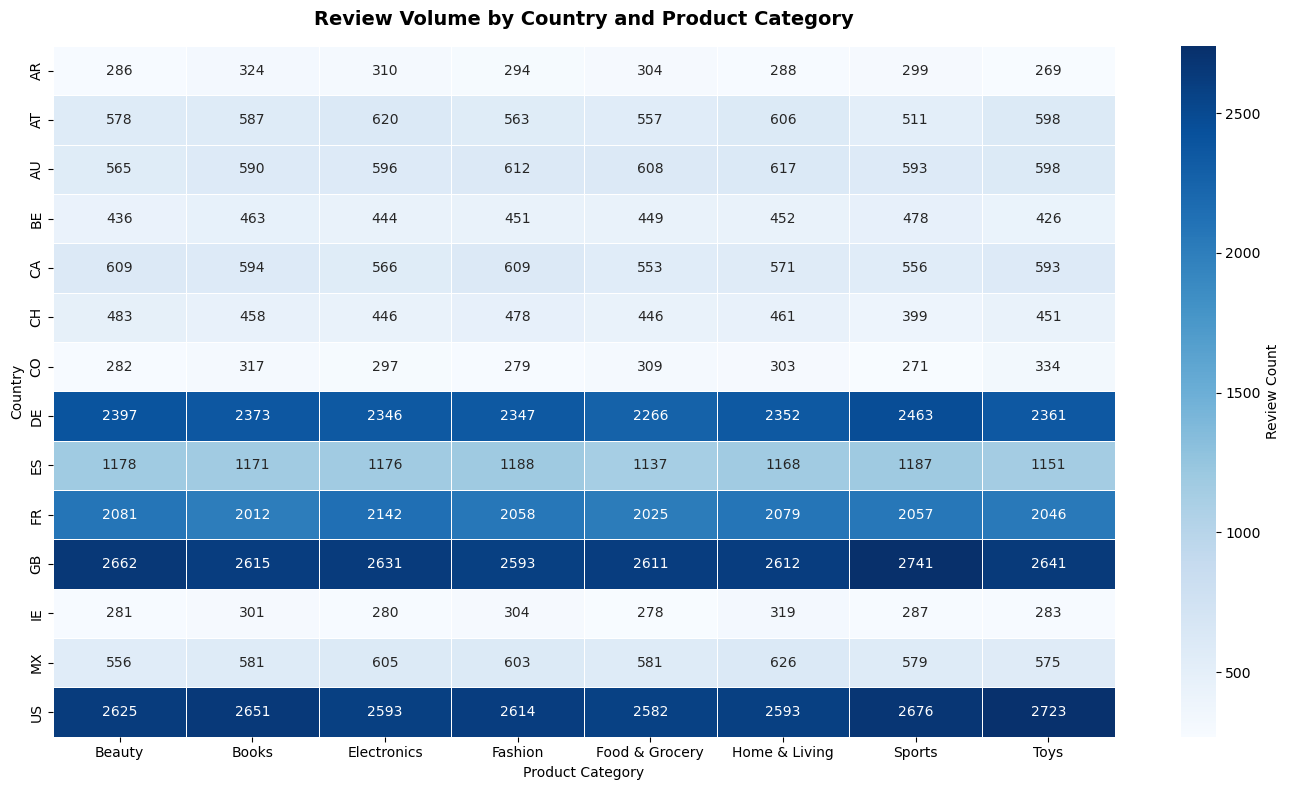

In [10]:
# Total reviews per category per country
category_country = df.groupby(['product_category', 'country']).size().reset_index(name='review_count')

# Top country per category
top_country_per_category = category_country.loc[
    category_country.groupby('product_category')['review_count'].idxmax()
].reset_index(drop=True)

top_country_per_category = top_country_per_category.sort_values('review_count', ascending=False)

for _, row in top_country_per_category.iterrows():
    print(f"{row['product_category']:<20} {row['country']:<10} {row['review_count']:,} reviews")

# Visualise — heatmap of category vs country
pivot = df.groupby(['country', 'product_category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Review Count'})

ax.set_title('Review Volume by Country and Product Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category')
ax.set_ylabel('Country')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'category_country_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

GB leads review volume across Sports (2,741), Beauty (2,662), 
Electronics (2,631), Home & Living (2,612) and Food & Grocery (2,611). 
The US leads in Toys (2,723), Books (2,651) and Fashion (2,614), 
reflecting category preferences aligned with each market's consumer culture.

Germany and France are consistent mid-tier contributors across all 
categories, while smaller markets like Argentina, Colombia and Ireland 
contribute below 340 reviews per category, limiting the statistical 
reliability of category-level insights for those markets.

For ShopEase Europe's product teams, GB and US feedback should be 
weighted most heavily when making category-specific product decisions, 
given their dominant contribution to review volume across all eight 
product lines.